## **Tasa de abandono Usuario Telefonia**

**DESCRIPCION**
La perdida de abonados es un problema natural y actual de las redes de telecomunicaciones, se tiene varios escenarios para que se presente el cambio de operador o darse de baja totalmente de un servicio.
Las telecomunicaciones al ser un area grande se tiene servicio como Internet fijo y movil, telefonia fija y movil.
Los operadores de telecomunicacion con la finalidad de frenar este efecto, realizan varias acciones de markecting con la finalidad de que el usuario permanezca dentro de la red.

Dentro del análisis se realiza una revisión de usuarios versus servicio prestado y la probabilidad de abandono con la finalidad de tener una toma de desiciones pre abandono.

La database presenta 7040 muestras de una empresa de servicio de telefonia fija e internet tomada en un trimestre anual.


**HIPOTESIS**

1. Realizar un análisis de la tasa de abandono de usuarios en la empresa de telecomunicaciones.
2. Analisis comparativos de campos y caracteristicas de usuarios dentro de la empresa con respecto a la tasa de abandono.


**INDICE**



* ID_user - Identificacion de usuario
* gender - género de usuario
* Senior_Citizen - identificación si el usuario tiene tercera edad (0 menores a tercera edad, 1 tercera edad)
* Partner - identificación si el usuario tiene pareja.
* Dependents - indetificación si el usuario tiene dependientes.
* tenure - número de meses que el usuario se encuentra en la empresa de telecomunicaciones.
* Phone_Service - identificación si el usuario tiene servicio voz.
* Multiple_Lines - identificación si el usuario tiene mas de una línea.
* Internet_Service - identificación si el usuario tiene servicio de internet y los medios de comunicación.
* Online_Security - identificación si el usuario tiene servicio de seguridad en linea.
* Online_Backup - identificación si el usuario tiene servicio almacenamiento de respaldo.
* Device_Protection - identificación si el usuario tiene servicio proteccion hacia el terminal.
* Tech_Support - identificación si el usuario tiene servicio de soporte técnico.
* Streaming_TV - identificación si el usuario tiene servicio de TV en vivo.
* Streaming_Movies - identificación si el usuario tiene servicio Streaming de Peliculas.
* Contract - identificación del tipo de contrato que tiene el usuario.
* Paperless_Billing - identificación de facturación electrónica.
* Payment_Method - Método de pago.
* Monthly_Charges - Cargos Mensuales.
* Total_Charges - cargos acumulados por servicio durante el período de suscripción.
* Churn – indentificación de abandono.


**Importar database**

In [1]:
#importar archivo base de datos
import pandas as pd
file_id = '19YqMiwsjOs4tHudWEivBtMDDNq7352vo'
download_url = f'https://drive.google.com/uc?id={file_id}&export=download'
try:
    df = pd.read_csv(download_url, encoding='latin1')
    print("✅ Archivo cargado correctamente.")
    print("Primeras 5 filas:")
    print(df.head())
except Exception as e:
    print(f"❌ Ocurrió un error al leer el archivo. Verifica la configuración.")
    print(f"Error detallado: {e}")

✅ Archivo cargado correctamente.
Primeras 5 filas:
  ID_User  gender  Senior_Citizen Partner Dependents  tenure Phone_Service  \
0  1-EFGC  Female               0     Yes         No       1            No   
1  2-EFGC    Male               0      No         No      34           Yes   
2  3-EFGC    Male               0      No         No       2           Yes   
3  4-EFGC    Male               0      No         No      45            No   
4  5-EFGC  Female               0      No         No       2           Yes   

     Multiple_Lines        Internet_Service Online_Security  ...  \
0  No phone service  Digital suscriber line              No  ...   
1                No  Digital suscriber line             Yes  ...   
2                No  Digital suscriber line             Yes  ...   
3  No phone service  Digital suscriber line             Yes  ...   
4                No             Fiber optic              No  ...   

  Device_Protection Tech_Support Streaming_TV Streaming_Movies  \
0    

In [2]:
    # informacion de tabla
    print("\nInformación de Tabla:")
    df.info()


Información de Tabla:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7040 entries, 0 to 7039
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID_User            7040 non-null   object 
 1   gender             7040 non-null   object 
 2   Senior_Citizen     7040 non-null   int64  
 3   Partner            7040 non-null   object 
 4   Dependents         7040 non-null   object 
 5   tenure             7040 non-null   int64  
 6   Phone_Service      7040 non-null   object 
 7   Multiple_Lines     7040 non-null   object 
 8   Internet_Service   7040 non-null   object 
 9   Online_Security    7040 non-null   object 
 10  Online_Backup      7040 non-null   object 
 11  Device_Protection  7040 non-null   object 
 12  Tech_Support       7040 non-null   object 
 13  Streaming_TV       7040 non-null   object 
 14  Streaming_Movies   7040 non-null   object 
 15  Contract           7040 non-null   object 
 16  P

In [3]:
df.head(10)

,ID_User,gender,Senior_Citizen,Partner,Dependents,tenure,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,1-EFGC,Female,0,Yes,No,1,No,No phone service,Digital suscriber line,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,2-EFGC,Male,0,No,No,34,Yes,No,Digital suscriber line,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3-EFGC,Male,0,No,No,2,Yes,No,Digital suscriber line,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,4-EFGC,Male,0,No,No,45,No,No phone service,Digital suscriber line,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,5-EFGC,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,6-EFGC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,7-EFGC,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,8-EFGC,Female,0,No,No,10,No,No phone service,Digital suscriber line,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,9-EFGC,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,10-EFGC,Male,0,No,Yes,62,Yes,No,Digital suscriber line,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
def check_data(dataframe, head=5):

    print(20*"-" + "Información".center(20) + 20*"-")
    print(dataframe.info())
    print(20*"-" + "Matriz".center(20) + 20*"-")
    print(dataframe.shape)
    print("\n" + 20*"-" + "Primeros 5 datos".center(20) + 20*"-")
    print(dataframe.head())
    print("\n" + 20 * "-" + "Ultimos 5 datos".center(20) + 20 * "-")
    print(dataframe.tail())
    print("\n" + 20 * "-" + "Faltantes".center(20) + 20 * "-")
    print(dataframe.isnull().sum())
    print("\n" + 40 * "-" + "Descripcion de la tabla".center(40) + 40 * "-")
    #print(dataframe.describe().T)
    print(dataframe.describe([0.01, 0.05, 0.10, 0.50, 0.75, 0.90, 0.95, 0.99]).T)


check_data(df)

--------------------    Información     --------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7040 entries, 0 to 7039
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID_User            7040 non-null   object 
 1   gender             7040 non-null   object 
 2   Senior_Citizen     7040 non-null   int64  
 3   Partner            7040 non-null   object 
 4   Dependents         7040 non-null   object 
 5   tenure             7040 non-null   int64  
 6   Phone_Service      7040 non-null   object 
 7   Multiple_Lines     7040 non-null   object 
 8   Internet_Service   7040 non-null   object 
 9   Online_Security    7040 non-null   object 
 10  Online_Backup      7040 non-null   object 
 11  Device_Protection  7040 non-null   object 
 12  Tech_Support       7040 non-null   object 
 13  Streaming_TV       7040 non-null   object 
 14  Streaming_Movies   7040 non-null   object 
 15  Contract   

Columna Total_Charges en tipo Object se debe cambiar a Numericas

In [5]:
pd.to_numeric(df.Total_Charges, errors='coerce').isna()
df.Total_Charges = pd.to_numeric(df.Total_Charges, errors='coerce') # Using errors=coerce. It will replace all non-numeric values with NaN.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7040 entries, 0 to 7039
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID_User            7040 non-null   object 
 1   gender             7040 non-null   object 
 2   Senior_Citizen     7040 non-null   int64  
 3   Partner            7040 non-null   object 
 4   Dependents         7040 non-null   object 
 5   tenure             7040 non-null   int64  
 6   Phone_Service      7040 non-null   object 
 7   Multiple_Lines     7040 non-null   object 
 8   Internet_Service   7040 non-null   object 
 9   Online_Security    7040 non-null   object 
 10  Online_Backup      7040 non-null   object 
 11  Device_Protection  7040 non-null   object 
 12  Tech_Support       7040 non-null   object 
 13  Streaming_TV       7040 non-null   object 
 14  Streaming_Movies   7040 non-null   object 
 15  Contract           7040 non-null   object 
 16  Paperless_Billing  7040 

In [6]:
df["Churn"].value_counts()

,count
Churn,
No,5172
Yes,1868


In [7]:
df["Churn"] = df["Churn"].map({'No': 0, 'Yes': 1})
df["Churn"].value_counts()

,count
Churn,
0,5172
1,1868


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7040 entries, 0 to 7039
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID_User            7040 non-null   object 
 1   gender             7040 non-null   object 
 2   Senior_Citizen     7040 non-null   int64  
 3   Partner            7040 non-null   object 
 4   Dependents         7040 non-null   object 
 5   tenure             7040 non-null   int64  
 6   Phone_Service      7040 non-null   object 
 7   Multiple_Lines     7040 non-null   object 
 8   Internet_Service   7040 non-null   object 
 9   Online_Security    7040 non-null   object 
 10  Online_Backup      7040 non-null   object 
 11  Device_Protection  7040 non-null   object 
 12  Tech_Support       7040 non-null   object 
 13  Streaming_TV       7040 non-null   object 
 14  Streaming_Movies   7040 non-null   object 
 15  Contract           7040 non-null   object 
 16  Paperless_Billing  7040 

Se realiza análisis gráfico como herramienta los histogramas de MATPLOTLIB mirando las variables numericas dando los siguientes resultados:
1. Usuarios menores a la tercera edad son 5 veces mas usuarios que los usuarios de tercera edad.
2. Se tiene un gran numero de nuevos usuarios iniciales los priemros 10 meses, y asu vez un gran numero de usuarios que superan los 70 meses.
3. Las cargas mensuales menores o iguales a 20 dólares son 3 veces mas que las de mayor valoración.
4. El total de recargas muestra superioridad entre los 0 a 500 dolares
5. Se evidencia que una cuarta parte de usuarios abandona la operadora en un trimestre del año.

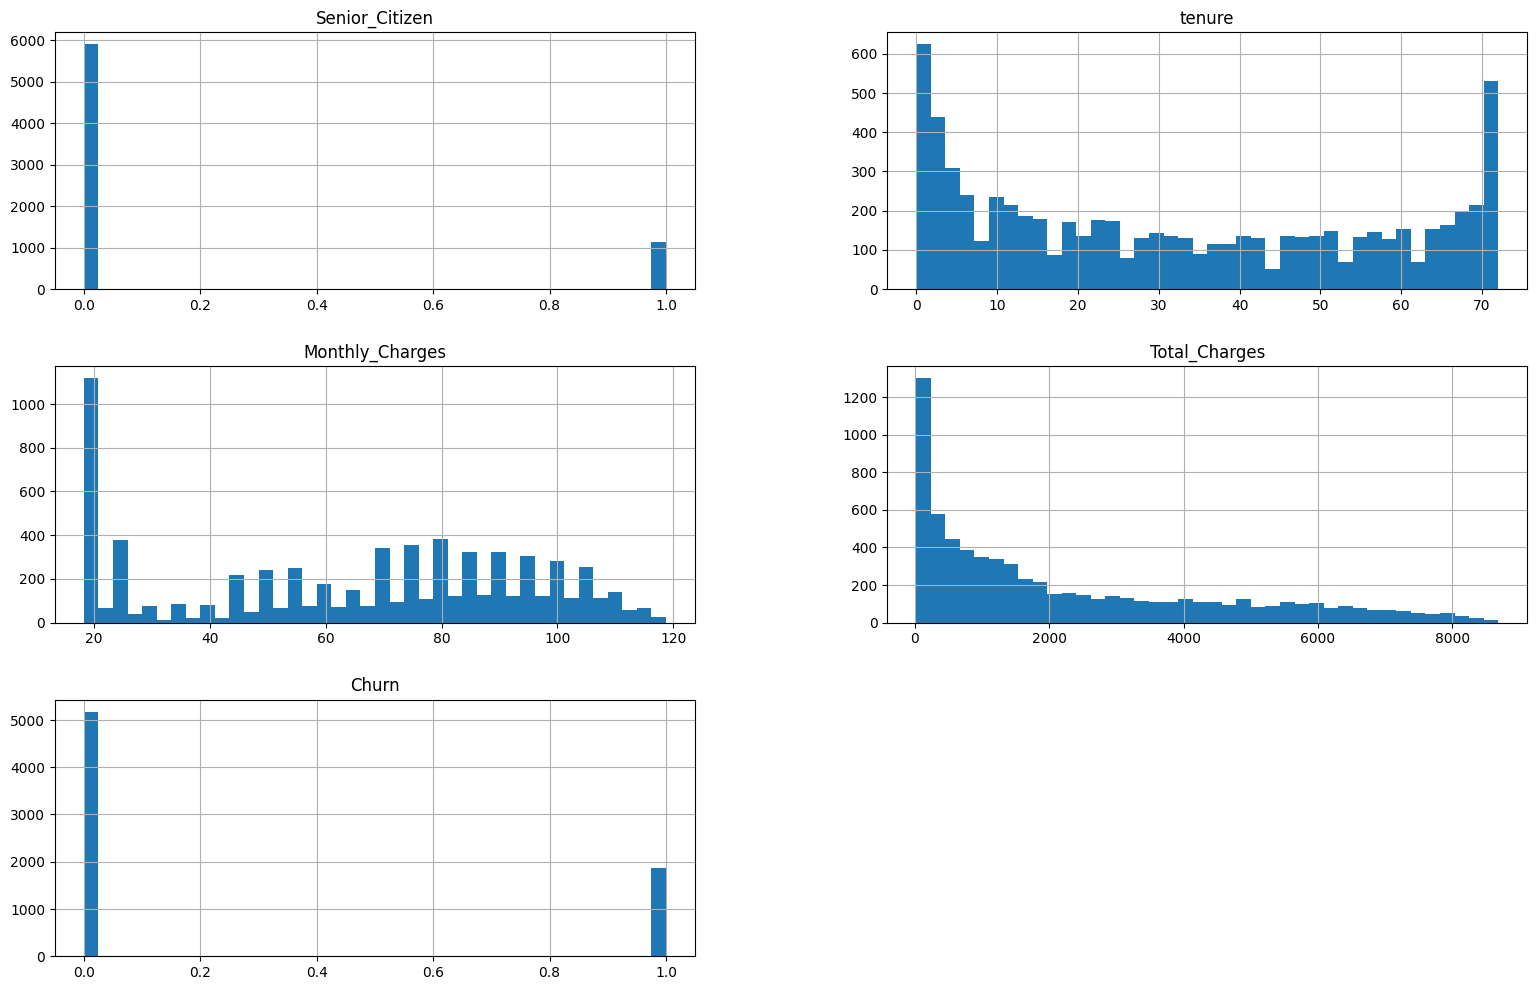

In [9]:
import matplotlib.pyplot as plt
num_bins = 40
df.hist(bins=num_bins, figsize=(19,12))
plt.savefig("churn_histogram")
plt.show()

Importar librerias

In [10]:
import seaborn as sns
import numpy as np

Se genera una nueva columna con la intensión de tener a nivel de cadena de caracteres el significado de la columna Senior_Citizen

In [11]:
df['Senior_Citizen_name'] = np.nan
df['Senior_Citizen_name'] = df['Senior_Citizen_name'].astype(object) # Explicitly cast to object type
df.loc[df['Senior_Citizen']==0, 'Senior_Citizen_name'] = 'menores de tercera edad'
df.loc[df['Senior_Citizen']==1, 'Senior_Citizen_name'] = 'tercera edad'
df

,ID_User,gender,Senior_Citizen,Partner,Dependents,tenure,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn,Senior_Citizen_name
0,1-EFGC,Female,0,Yes,No,1,No,No phone service,Digital suscriber line,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,menores de tercera edad
1,2-EFGC,Male,0,No,No,34,Yes,No,Digital suscriber line,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,menores de tercera edad
2,3-EFGC,Male,0,No,No,2,Yes,No,Digital suscriber line,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,menores de tercera edad
3,4-EFGC,Male,0,No,No,45,No,No phone service,Digital suscriber line,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,menores de tercera edad
4,5-EFGC,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,menores de tercera edad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7035,7036-EFGC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.10,0,menores de tercera edad
7036,7037-EFGC,Female,0,No,No,12,No,No phone service,Digital suscriber line,No,...,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.30,0,menores de tercera edad
7037,7038-EFGC,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,0,menores de tercera edad
7038,7039-EFGC,Male,0,Yes,Yes,24,Yes,Yes,Digital suscriber line,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,menores de tercera edad


Se genera una tabla dinámica con la finalidad de obtener el porcentaje de abandono por genero y por edad.
El resultado muestra el porcentaje acorde a los evidenciado en los histogramas el mayor numero de usuarios hacia personas menores a tercera edad.  

In [12]:
pd.pivot_table(df,
               index=['Senior_Citizen_name'],
               columns= ['gender'],
               values=['Churn'],
               aggfunc="sum")/df["gender"].count()*100

Churn          
gender                     Female      Male
Senior_Citizen_name                        
menores de tercera edad  9.928977  9.857955
tercera edad             3.409091  3.338068

Se evidencia que los contratos mes a mes tiene la mayoria de abonados.

In [13]:
df['Contract'].value_counts(dropna=False)

,count
Contract,
Month-to-month,3873
Two year,1694
One year,1473


Se evidencia que el mayor numero de abandono se da en contratos de mes a mes, y el menor indice de abandono serian para contratos de 2 años, lo que indica que dentro del analisis de nuevos abonados lo preferencial seria firmar a largo plazo la contratación.

In [14]:
pd.pivot_table(df,
               index=['Contract'],
               columns= ['Payment_Method'],
               values=['Churn'],
               aggfunc="sum")/df["Payment_Method"].count()*100

Churn                          \
Payment_Method Bank transfer (automatic) Credit card (automatic)   
Contract                                                           
Month-to-month                  2.855114                2.528409   
One year                        0.539773                0.582386   
Two year                        0.269886                0.184659   

                                              
Payment_Method Electronic check Mailed check  
Contract                                      
Month-to-month        14.119318     3.991477  
One year               0.909091     0.326705  
Two year               0.184659     0.042614

Crear una nueva columna con un mejor calificativo al tiempo de fidelidad al usuario.

In [15]:
# Definimos los límites de los rangos (bins)
# El primer número es el inicio y el último el final
limites = [0, 12, 18, 24, 36, np.inf]

# Definimos las etiquetas para cada rango
etiquetas = ['nuevo usuario', 'usuario fiel', 'usuario legal', 'usuario senior', 'mejores usuarios']

# Creamos la columna nueva
df['tenure_name'] = pd.cut(df['tenure'], bins=limites, labels=etiquetas, right=False)

df

,ID_User,gender,Senior_Citizen,Partner,Dependents,tenure,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn,Senior_Citizen_name,tenure_name
0,1-EFGC,Female,0,Yes,No,1,No,No phone service,Digital suscriber line,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,menores de tercera edad,nuevo usuario
1,2-EFGC,Male,0,No,No,34,Yes,No,Digital suscriber line,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,0,menores de tercera edad,usuario senior
2,3-EFGC,Male,0,No,No,2,Yes,No,Digital suscriber line,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,menores de tercera edad,nuevo usuario
3,4-EFGC,Male,0,No,No,45,No,No phone service,Digital suscriber line,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,menores de tercera edad,mejores usuarios
4,5-EFGC,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,menores de tercera edad,nuevo usuario
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7035,7036-EFGC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.10,0,menores de tercera edad,usuario legal
7036,7037-EFGC,Female,0,No,No,12,No,No phone service,Digital suscriber line,No,...,Yes,Yes,One year,No,Electronic check,60.65,743.30,0,menores de tercera edad,usuario fiel
7037,7038-EFGC,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,0,menores de tercera edad,mejores usuarios
7038,7039-EFGC,Male,0,Yes,Yes,24,Yes,Yes,Digital suscriber line,Yes,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,menores de tercera edad,usuario senior


Tabla dinámica con tipos de contratos y calificativo de antiguedad de contrato, mostrando los valores de abandono del servicio.

In [16]:
pd.pivot_table(df,
               index=['Contract'],
               columns= ['tenure_name'],
               values=['Churn'],
               aggfunc="sum")/df["tenure_name"].count()*100

/tmp/ipykernel_186/1095968485.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(df,


Churn                                            \
tenure_name    nuevo usuario usuario fiel usuario legal usuario senior   
Contract                                                                 
Month-to-month     14.062500     2.585227      1.505682       2.443182   
One year            0.113636     0.127841      0.170455       0.269886   
Two year            0.000000     0.000000      0.000000       0.028409   

                                 
tenure_name    mejores usuarios  
Contract                         
Month-to-month         2.897727  
One year               1.676136  
Two year               0.653409

# **Análisis de variables numericas y categoricas**

In [18]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    pass

In [19]:
import pandas.api.types as pd_types # Import for robust type checking

def grab_col_names(dataframe, cat_th=10, car_th=20):

    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and pd_types.is_numeric_dtype(dataframe[col])]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and dataframe[col].dtypes == "O"]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if pd_types.is_numeric_dtype(dataframe[col])]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, num_cols, cat_but_car


cat_cols, num_cols, cat_but_car = grab_col_names(df)

cat_cols
num_cols

Observations: 7040
Variables: 23
cat_cols: 18
num_cols: 3
cat_but_car: 1
num_but_cat: 2


['tenure', 'Monthly_Charges', 'Total_Charges']

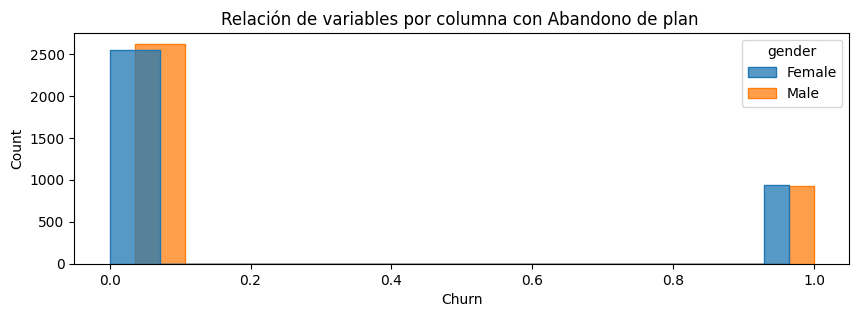

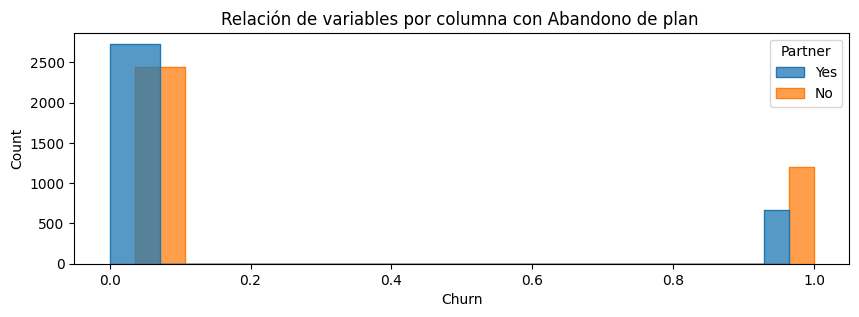

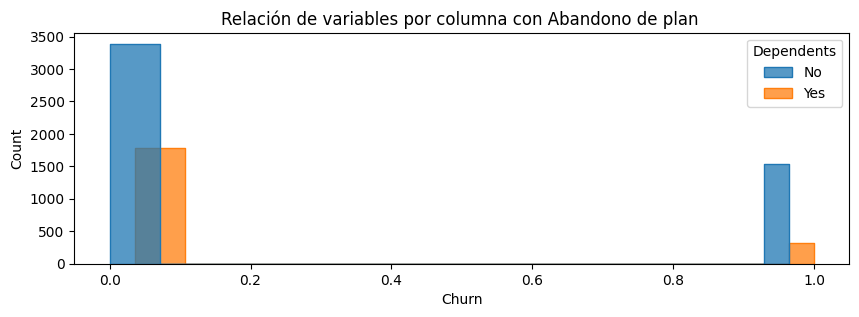

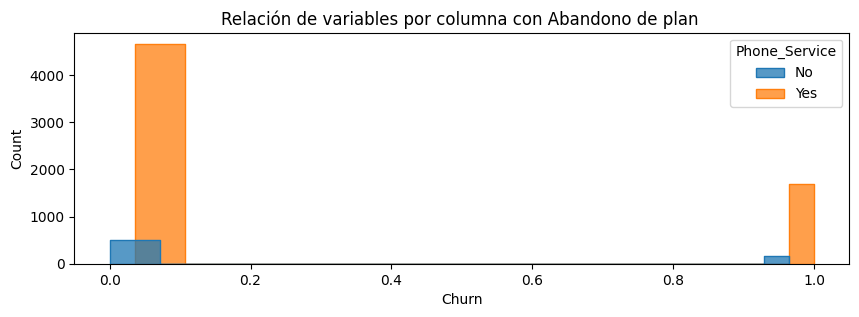

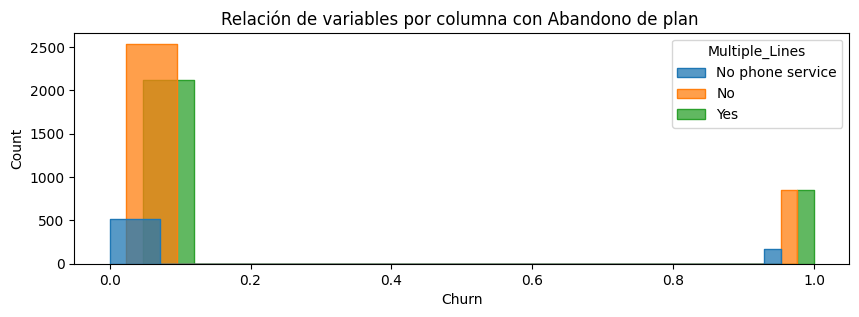

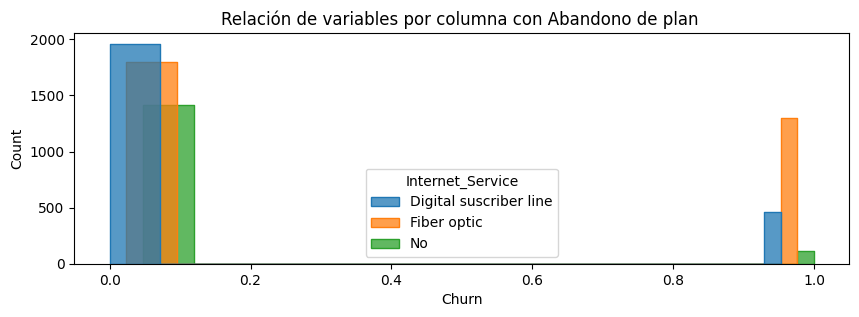

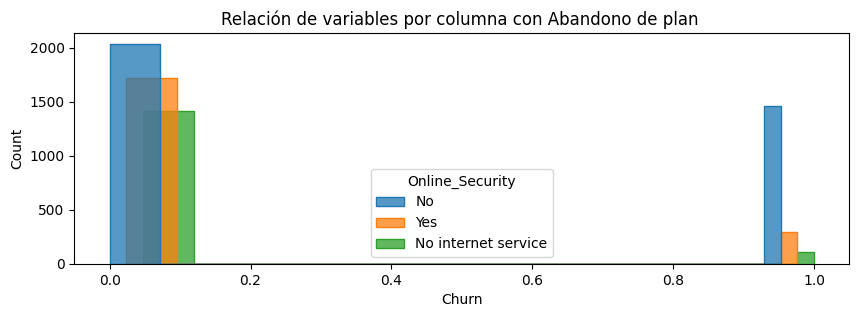

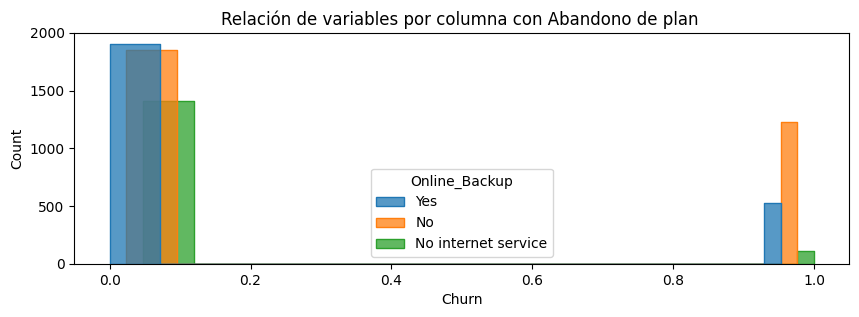

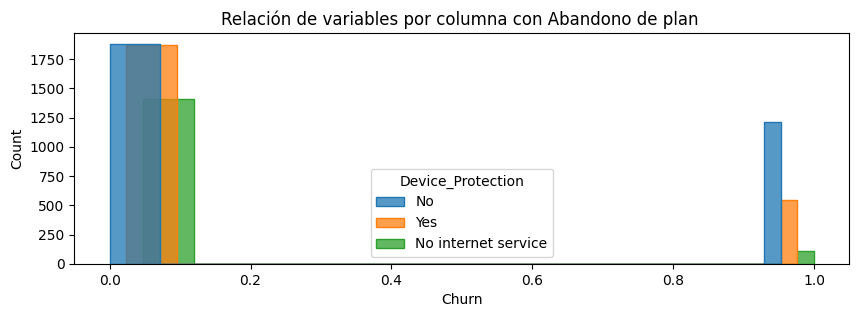

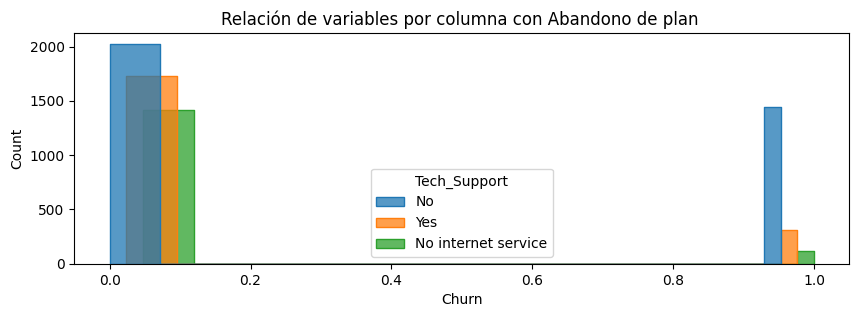

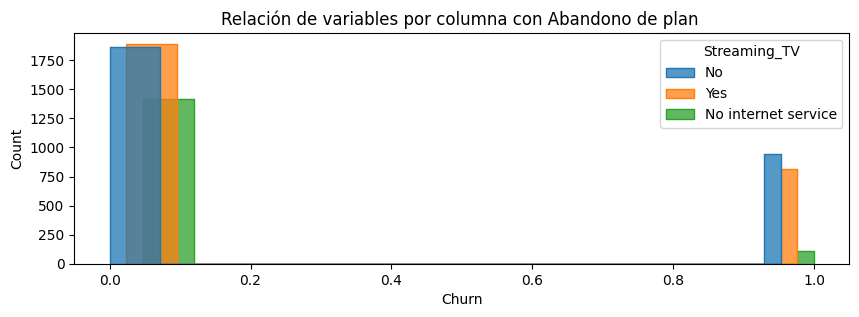

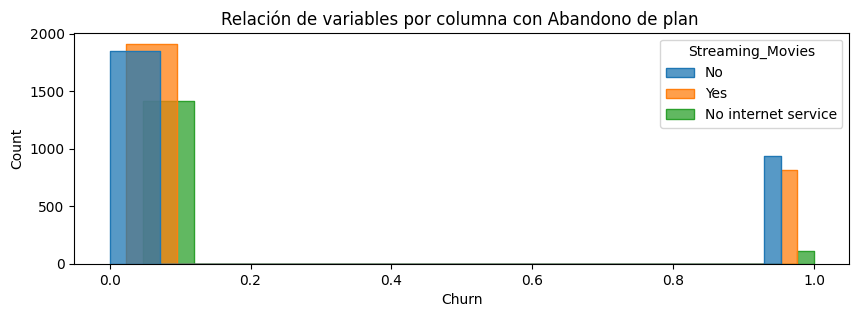

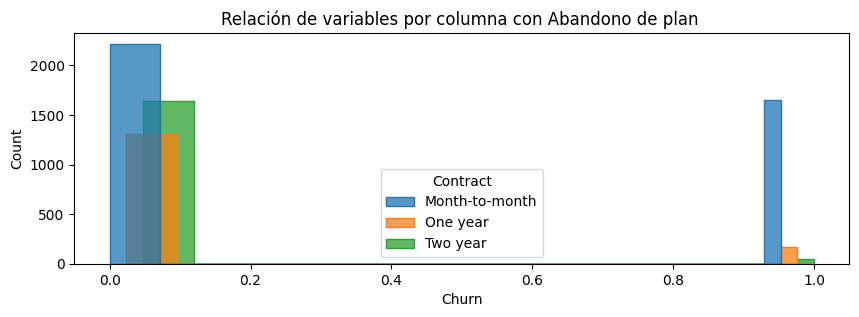

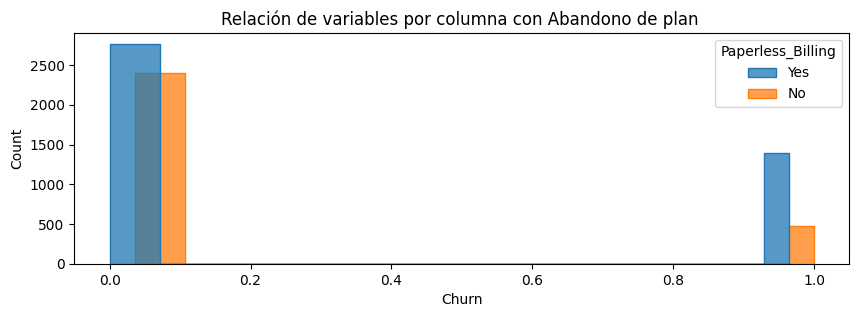

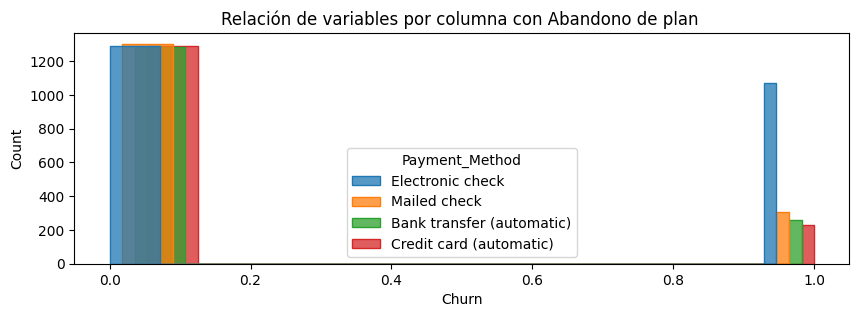

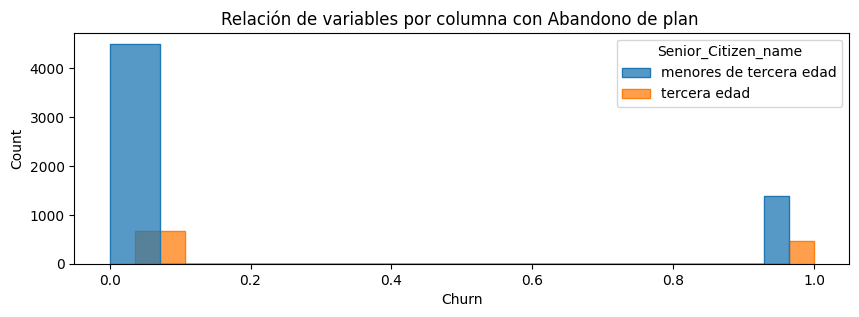

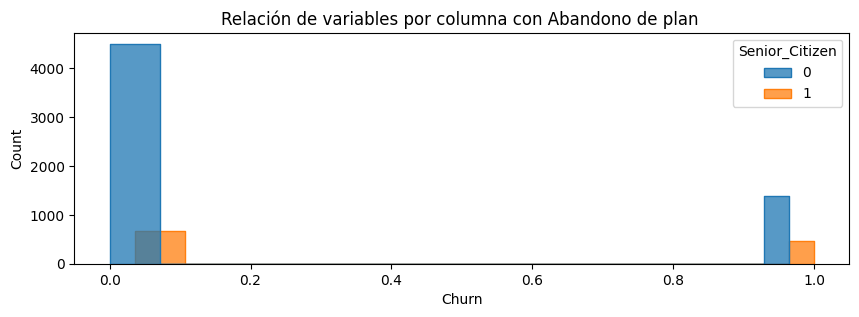

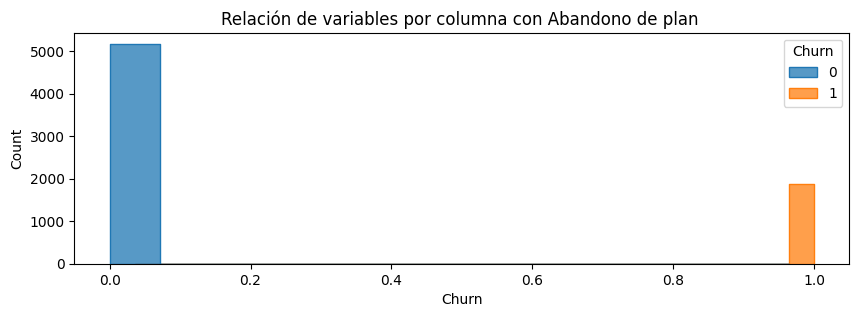

In [20]:
def target_vs_category_visual(dataframe, target, categorical_col):
    plt.figure(figsize=(10, 3))
    sns.histplot(x=target, hue=categorical_col, data=dataframe, element="step", multiple="dodge")
    plt.title("Relación de variables por columna con Abandono de plan ")
    plt.show()


for col in cat_cols:
    target_vs_category_visual(df, "Churn", col)

A continuación la presentacion y relaciones con indice de abandono por categoria y columna.

Se evidencia lo mencionado anteriormente a nivel de tablas.

La diferencia no es significativa en el número de abandonos entre hombres y mujeres.

La tasa de abandono de los clientes que pagan con cheque electrónico es alta.

Los clientes con contratos mensuales tienen alta tasa de abandono.

Los clientes que utilizan internet de fibra óptica tienen alta tasa de abandono.

In [21]:
def target_summary_with_cat(dataframe, target, categorical_col):
    print(pd.DataFrame({"CHURN_MEAN": dataframe.groupby(categorical_col)[target].mean()}))


for col in cat_cols:
    target_summary_with_cat(df, "Churn", col)

        CHURN_MEAN
gender            
Female    0.269286
Male      0.261469
         CHURN_MEAN
Partner            
No         0.329670
Yes        0.196471
            CHURN_MEAN
Dependents            
No            0.312715
Yes           0.154576
               CHURN_MEAN
Phone_Service            
No               0.249633
Yes              0.267023
                  CHURN_MEAN
Multiple_Lines              
No                  0.250516
No phone service    0.249633
Yes                 0.285859
                        CHURN_MEAN
Internet_Service                  
Digital suscriber line    0.189669
Fiber optic               0.418875
No                        0.074050
                     CHURN_MEAN
Online_Security                
No                     0.417501
No internet service    0.074050
Yes                    0.146257
                     CHURN_MEAN
Online_Backup                  
No                     0.399352
No internet service    0.074050
Yes                    0.215315
        

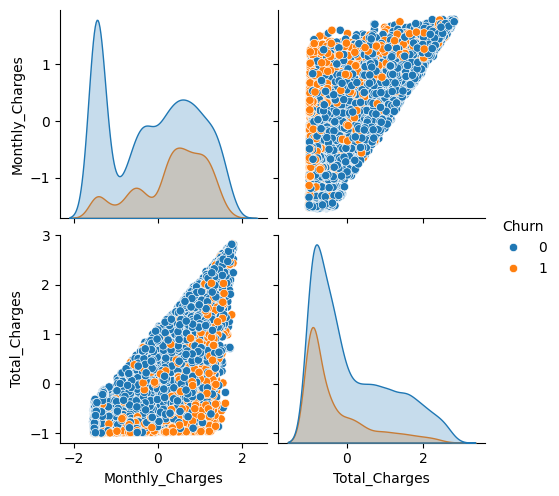

In [37]:
sns.pairplot(df[['Monthly_Charges', 'Churn', 'Total_Charges']], hue='Churn')

In [22]:
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    # Apply .any() directly to the boolean series, not the filtered DataFrame
    if ((dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)).any():
        return True
    else:
        return False

def grab_outliers(dataframe, col_name, index=False):
    low, up = outlier_thresholds(dataframe, col_name)

    if dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].shape[0] > 10:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].head())
    else:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))])

    if index:
        outlier_index = dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].index
        return outlier_index

for col in num_cols:
    print(col, check_outlier(df, col))

tenure False
Monthly_Charges False
Total_Charges False


## **Revision de faltantes**

In [23]:
def missing_values_table(dataframe, na_name=False):
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])
    print(missing_df, end="\n")

    if na_name:
        return na_columns


missing_values_table(df)

               n_miss  ratio
Total_Charges      11   0.16


# **Correlacion**

In [24]:
corr_matrix = df[num_cols].corr()
corr_matrix

,tenure,Monthly_Charges,Total_Charges
tenure,1.000000,0.247672,0.825798
Monthly_Charges,0.247672,1.000000,0.650983
Total_Charges,0.825798,0.650983,1.000000


Correlacion entre todas las columnas

Los resultados de la correlación, muestran:

Correlación positiva entre tasa de abandono con la edad de clientes, se evidencia que un gran porcentaje de personas de la tercera edad abandonan los planes.

Adicional se nota que a mayor antiguedad se tiene mayor fidelidad y no abandono del operador.

A mayor cargas mensuales incremento de abandono. Sin embargo las cargas totales con inversamente a la tasa de abandono.

La explicación podría ser que los cargos totales también dependen del tiempo que el cliente lleva en una empresa (la antigüedad tiene una correlación negativa). Además, es cuestionable si TotalCharges es una variable adecuada para comprender el comportamiento del cliente y si este lo monitoriza.

Una correlación positiva entre la facturación electrónica y la tasa de abandono es algo que requiere mayor investigación (no está claro qué puede ser la causa de dicho comportamiento).

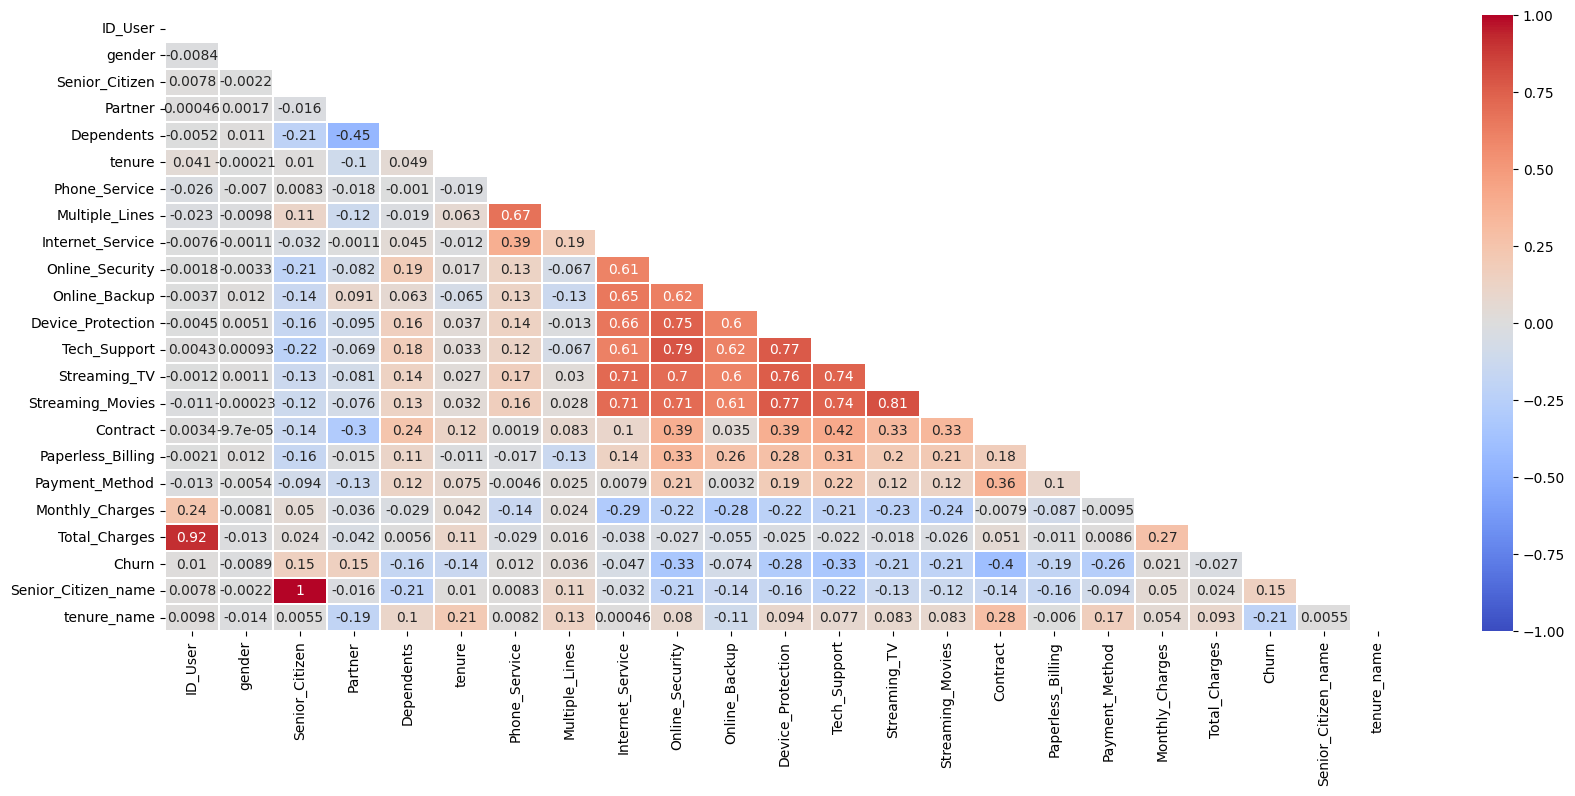

In [25]:
plt.figure(5, figsize=(20, 8))
corr = df.apply(lambda x: pd.factorize(x)[0]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

Aplicacion de LABEL ENCODER

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = [col for col in df.columns if df[col].dtype not in [int, float]
               and df[col].nunique() == 2]

def label_encoder(dataframe, binary_col):
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe

for col in binary_cols:
    df = label_encoder(df, col)

def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe

ohe_cols = [col for col in df.columns if 30 >= df[col].nunique() > 2]

df = one_hot_encoder(df, ohe_cols)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7040 entries, 0 to 7039
Data columns (total 37 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   ID_User                                 7040 non-null   object 
 1   gender                                  7040 non-null   int64  
 2   Senior_Citizen                          7040 non-null   int64  
 3   Partner                                 7040 non-null   int64  
 4   Dependents                              7040 non-null   int64  
 5   tenure                                  7040 non-null   int64  
 6   Phone_Service                           7040 non-null   int64  
 7   Paperless_Billing                       7040 non-null   int64  
 8   Monthly_Charges                         7040 non-null   float64
 9   Total_Charges                           7029 non-null   float64
 10  Churn                                   7040 non-null   int6

In [28]:
df

,ID_User,gender,Senior_Citizen,Partner,Dependents,tenure,Phone_Service,Paperless_Billing,Monthly_Charges,Total_Charges,...,Streaming_Movies_Yes,Contract_One year,Contract_Two year,Payment_Method_Credit card (automatic),Payment_Method_Electronic check,Payment_Method_Mailed check,tenure_name_usuario fiel,tenure_name_usuario legal,tenure_name_usuario senior,tenure_name_mejores usuarios
0,1-EFGC,0,0,1,0,1,0,1,29.85,29.85,...,False,False,False,False,True,False,False,False,False,False
1,2-EFGC,1,0,0,0,34,1,0,56.95,1889.50,...,False,True,False,False,False,True,False,False,True,False
2,3-EFGC,1,0,0,0,2,1,1,53.85,108.15,...,False,False,False,False,False,True,False,False,False,False
3,4-EFGC,1,0,0,0,45,0,0,42.30,1840.75,...,False,True,False,False,False,False,False,False,False,True
4,5-EFGC,0,0,0,0,2,1,1,70.70,151.65,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7035,7036-EFGC,1,0,0,0,19,1,1,78.70,1495.10,...,False,False,False,False,False,False,False,True,False,False
7036,7037-EFGC,0,0,0,0,12,0,0,60.65,743.30,...,True,True,False,False,True,False,True,False,False,False
7037,7038-EFGC,0,0,0,0,72,1,1,21.15,1419.40,...,False,False,True,False,False,False,False,False,False,True
7038,7039-EFGC,1,0,1,1,24,1,1,84.80,1990.50,...,True,True,False,False,False,True,False,False,True,False


# **Estandarizacion de variables numericas**

Mostrando valores estandar para las columnas numericas

In [29]:
from sklearn.preprocessing import StandardScaler
num_cols = [col for col in num_cols if col not in "ID_User"]
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df[num_cols].head()

,tenure,Monthly_Charges,Total_Charges
0,-1.277626,-1.160276,-0.994333
1,0.066239,-0.259562,-0.173731
2,-1.236902,-0.362596,-0.959782
3,0.514194,-0.746480,-0.195242
4,-1.236902,0.197442,-0.940587
